<a href="https://colab.research.google.com/github/MBR4V0/Python/blob/main/Ajustes2_Parametros_XGBost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [419]:
from google.colab import drive


In [420]:
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [421]:
import os


In [422]:
"Aqui pode-se consultar as pastas que tem no arquivo DRIVE"
os.listdir('/content/drive/MyDrive')


['CNH-e (1).pdf',
 'CNH-e.pdf',
 'bl.351859139_40607751182_002003202402.03242024065419.temp.output.pdf',
 'Solicitação para Reforma.docx',
 'Solicitação para Reforma.gdoc',
 'Cópia de Solicitação para Reforma.docx',
 'Cópia de Cópia de Solicitação para Reforma.gdoc',
 'Cópia de Cópia de Solicitação para Reforma (1).docx',
 'Cópia de Cópia de Solicitação para Reforma.docx',
 'brModelo.jar',
 'Colab Notebooks',
 'autosave.chc',
 'Apresentação da empresa 3.pptx',
 'GITMAN, Principios Adm Financeira 2010.pdf',
 'ASSAF NETO, A. Finanças Corporativas e Valor.pdf',
 'ASSAF NETO Matematica-Financeira-e-Suas-Aplicacoes.pdf',
 'HAZZAN SAMUELfundamentos-da-matematica-elementar-e outros.pdf',
 'HOJI, M. Adm financeira e orçamentaria.pdf',
 'VASCONCELLOS e outros Manual-de-economia-e-negocios-internacionais.pdf',
 'Dados_Tratados',
 'Dados_teste']

In [423]:
os.listdir('/content/drive/MyDrive/Dados_teste')

['dados.xlsx']

**Etapa 9 — Instalar/importar o Pandas**

In [424]:
import pandas as pd

In [425]:
df = pd.read_excel(
    '/content/drive/MyDrive/Dados_teste/dados.xlsx'
)


In [468]:
df.head(50)

,Idade,Tumor_cm,Linfonodos,Ki67,TN
0,49,2.1,3,70,1
1,35,1.2,0,15,0
2,38,3.4,5,80,1
3,49,1.5,1,25,0
4,60,2.8,4,65,1
5,53,1.1,0,10,0
6,48,2.9,3,75,1
7,34,1.8,1,30,0
8,47,4.2,6,85,1
9,41,2.3,2,45,0


E se você quiser trabalhar com um Excel que está no seu computador?

In [469]:
"from google.colab import files"

"arquivo = files.upload()"

'arquivo = files.upload()'

In [470]:
df.head()


,Idade,Tumor_cm,Linfonodos,Ki67,TN
0,49,2.1,3,70,1
1,35,1.2,0,15,0
2,38,3.4,5,80,1
3,49,1.5,1,25,0
4,60,2.8,4,65,1


In [471]:
df.shape


(1845, 5)

**Random Forest**

In [472]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [473]:
X = df[['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67']]

In [474]:
y = df['TN']

In [475]:
print("X:")
display(X)

print("y:")
display(y)

X:


,Idade,Tumor_cm,Linfonodos,Ki67
0,49,2.1,3,70
1,35,1.2,0,15
2,38,3.4,5,80
3,49,1.5,1,25
4,60,2.8,4,65
...,...,...,...,...
1840,67,3.6,6,82
1841,64,2.0,1,28
1842,34,3.8,8,88
1843,34,1.5,0,18


y:


,TN
0,1
1,0
2,1
3,0
4,1
...,...
1840,1
1841,0
1842,1
1843,0


**Separar treinamento e teste (70% dos dados para ensinar o modelo e 30% para testar.)**

In [476]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=45
)

In [478]:
print("Treinamento:", len(X_treino))
print("Teste:", len(X_teste))

Treinamento: 1476
Teste: 369


**Criar o XGBost**

In [436]:
!pip install -q xgboost

In [479]:
from xgboost import XGBClassifier


In [480]:
modelo_xgb = XGBClassifier(
    n_estimators=20,
    max_depth=2,
    learning_rate=0.5,
    random_state=45
)

In [481]:
modelo_xgb.fit(
    X_treino,
    y_treino
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.5, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=20,
              n_jobs=None, num_parallel_tree=None, ...)

**Fazendo as previsões**

In [482]:
previsao_xgbost = modelo_xgb.predict(
    X_teste
)

In [483]:
previsao_xgb = modelo_xgb.predict(X_teste)


In [484]:
print("Total de pacientes:", len(df))

print("\nDistribuição das classes:")
print(df['TN'].value_counts())

print("\nTreinamento:", len(X_treino))
print("Teste:", len(X_teste))

Total de pacientes: 1845

Distribuição das classes:
TN
1    923
0    922
Name: count, dtype: int64

Treinamento: 1476
Teste: 369


In [485]:
print("Real:")
print(y_teste.values)

print()

print("Previsão:")
print(previsao_xgbost)


Real:
[0 1 1 1 1 0 0 0 1 1 0 0 0 1 0 0 1 0 1 1 1 0 1 0 1 0 1 1 0 0 0 1 0 1 1 0 1
 1 0 1 0 1 0 1 0 1 1 0 1 1 0 1 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 0 0
 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 1 0 1 1 0 0 1 0 0 1 0 1 1 1 0 0 0 1 1 0 1 0
 0 0 0 0 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 1 1 1 1 0 0
 0 0 1 1 0 1 0 0 0 0 1 0 0 1 1 1 0 1 0 0 1 0 0 1 1 1 1 1 1 0 0 1 0 1 1 1 1
 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 1 1 1 1 0 0 1 1 0 0 1 0 0
 1 0 0 0 1 0 1 0 1 0 1 1 1 1 0 0 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0 1 1 0 1
 1 0 1 1 0 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 1 0 1 1 0 0 1
 0 0 1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1
 0 0 1 0 1 1 0 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0]

Previsão:
[0 1 1 1 1 0 0 0 1 1 0 0 0 1 0 0 1 0 1 1 1 0 1 0 1 0 1 1 0 0 0 1 0 1 1 0 1
 1 0 1 0 1 0 1 0 1 1 0 1 1 0 1 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 0 0
 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 1 0 1 1 0 0 1 0 0 1 0 1 1 1 0 0 0 1 1 0 1 0
 0 0 0 0 

In [486]:
acuracia_xgb = accuracy_score(
    y_teste,
    previsao_xgb
)

In [487]:
print(
    f"Acurácia XGBoost: {acuracia_xgb:.2%}"
)

Acurácia XGBoost: 100.00%


### Matriz de Confusão

A matriz de confusão é uma ferramenta útil para visualizar o desempenho de um algoritmo de classificação. Ela mostra o número de previsões corretas e incorretas para cada classe, permitindo identificar onde o modelo está errando.

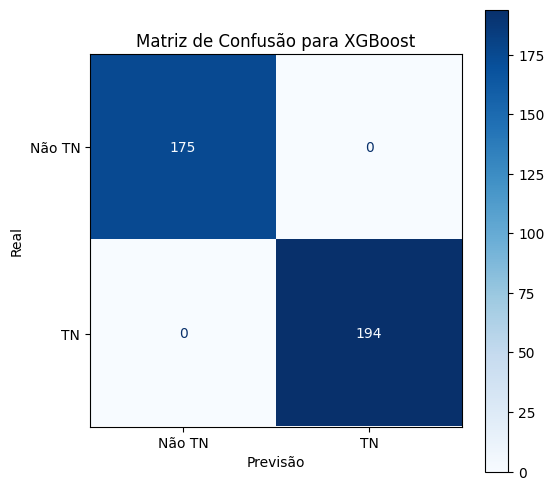

In [488]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calcule a matriz de confusão
cm = confusion_matrix(y_teste, previsao_xgbost)

# Defina os rótulos das classes (se você souber, caso contrário, será 0, 1, 2...)
# Assumindo que as classes são 0 e 1, com base nos valores de 'TN' no seu df
class_names = ['Não TN', 'TN']

# Crie a visualização da matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plote a matriz de confusão
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Matriz de Confusão para XGBoost')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()


In [489]:
print("Total de dados:", len(df))

print("\nTreinamento:", len(X_treino))
print("Teste:", len(X_teste))

print("\nAcurácia no TREINAMENTO:")

previsao_treino = modelo_xgb.predict(X_treino)

print(
    accuracy_score(
        y_treino,
        previsao_treino
    )
)

print("\nAcurácia no TESTE:")

previsao_teste = modelo_xgb.predict(X_teste)

print(
    accuracy_score(
        y_teste,
        previsao_teste
    )
)


Total de dados: 1845

Treinamento: 1476
Teste: 369

Acurácia no TREINAMENTO:
1.0

Acurácia no TESTE:
1.0


In [490]:
"Visão Geral"
print("\nClasses reais no teste:")
print(y_teste.value_counts())

print("\nPrevisões no teste:")
print(pd.Series(previsao_teste).value_counts())



Classes reais no teste:
TN
1    194
0    175
Name: count, dtype: int64

Previsões no teste:
1    194
0    175
Name: count, dtype: int64


In [491]:
"Teste 1 - Existe vazamento de dados (leakage) ?"
print("Variáveis usadas no modelo:")
print(X.columns.tolist())

print("\nVariável alvo:")
print(y.name)


Variáveis usadas no modelo:
['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67']

Variável alvo:
TN


In [492]:
"Teste 2 - Dados duplicados ( Em excesso é ruim - Verificar )"
print("Total de linhas:", len(df))

print("Linhas duplicadas:", df.duplicated().sum())


Total de linhas: 1845
Linhas duplicadas: 179


In [493]:
"Teste 3 - Dados iguais no treinamento e teste ( Se for alto precisa tratar)"
treino_completo = X_treino.copy()
treino_completo['TN'] = y_treino.values

teste_completo = X_teste.copy()
teste_completo['TN'] = y_teste.values

duplicadas = pd.merge(
    treino_completo,
    teste_completo,
    how='inner'
)

print("Registros iguais encontrados entre treino e teste:")
print(len(duplicadas))


Registros iguais encontrados entre treino e teste:
73


In [494]:
"Teste 4"
print(
    df.groupby('TN')[['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67']]
      .mean()
)

        Idade  Tumor_cm  Linfonodos       Ki67
TN                                            
0   49.855748  1.827657    0.516269  22.426247
1   50.525460  3.536186    5.780065  79.191766


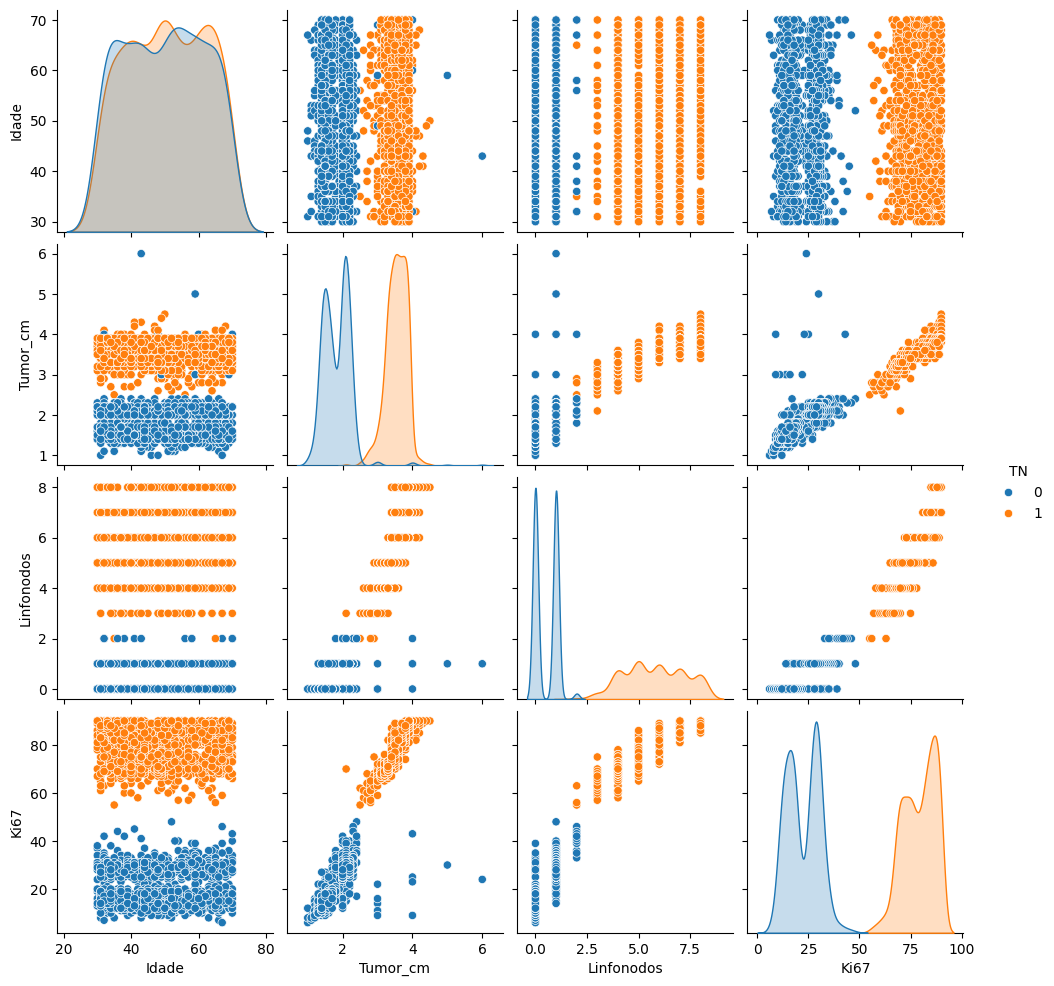

In [495]:
"Visualização Gráfica de Tendências"
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df[['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67', 'TN']],
    hue='TN'
)

plt.show()

In [496]:
"Correção de Duplicatas"
df_limpo = df.drop_duplicates().copy()

print("Antes:", len(df))
print("Depois:", len(df_limpo))
print("Removidas:", len(df) - len(df_limpo))

Antes: 1845
Depois: 1666
Removidas: 179


In [455]:
"Recriando X e Y"
X = df_limpo[
    ['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67']
]

y = df_limpo['TN']

In [456]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=45,
    stratify=y
)

In [457]:
"Conferindo se ainda existem Duplicatas"
treino_completo = X_treino.copy()
treino_completo['TN'] = y_treino.values

teste_completo = X_teste.copy()
teste_completo['TN'] = y_teste.values

duplicadas = pd.merge(
    treino_completo,
    teste_completo,
    how='inner'
)

print("Duplicatas entre treino e teste:", len(duplicadas))

Duplicatas entre treino e teste: 0


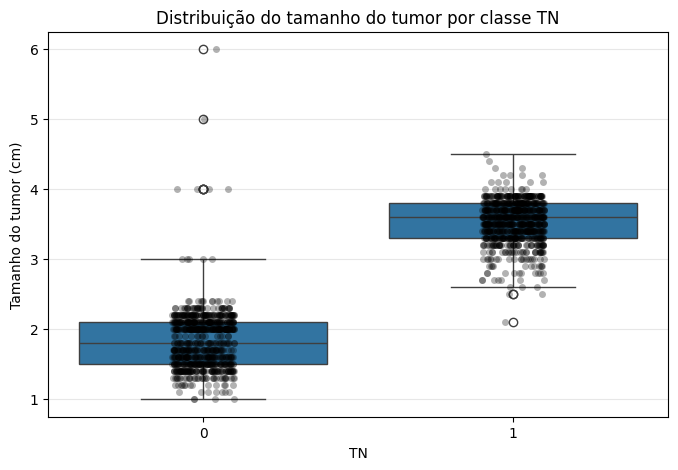

In [459]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_limpo,
    x='TN',
    y='Tumor_cm'
)

sns.stripplot(
    data=df_limpo,
    x='TN',
    y='Tumor_cm',
    color='black',
    alpha=0.3
)

plt.xlabel('TN')
plt.ylabel('Tamanho do tumor (cm)')
plt.title('Distribuição do tamanho do tumor por classe TN')
plt.grid(axis='y', alpha=0.3)

plt.show()


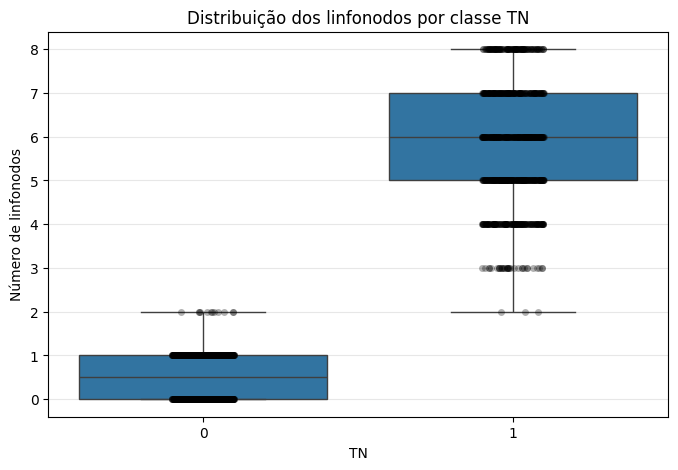

In [460]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_limpo,
    x='TN',
    y='Linfonodos'
)

sns.stripplot(
    data=df_limpo,
    x='TN',
    y='Linfonodos',
    color='black',
    alpha=0.3
)

plt.xlabel('TN')
plt.ylabel('Número de linfonodos')
plt.title('Distribuição dos linfonodos por classe TN')
plt.grid(axis='y', alpha=0.3)

plt.show()


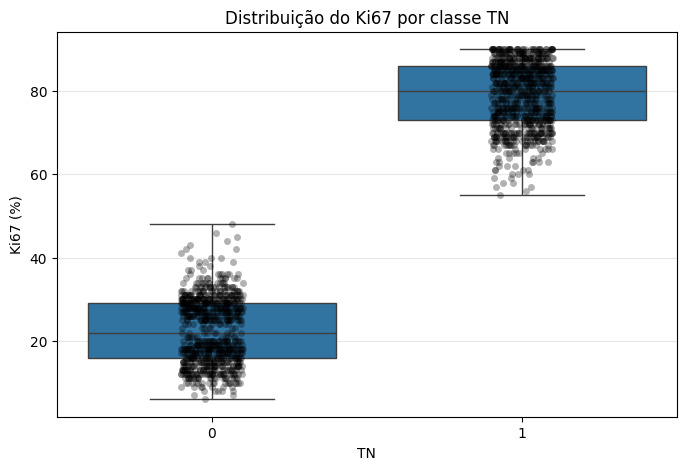

In [461]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_limpo,
    x='TN',
    y='Ki67'
)

sns.stripplot(
    data=df_limpo,
    x='TN',
    y='Ki67',
    color='black',
    alpha=0.3
)

plt.xlabel('TN')
plt.ylabel('Ki67 (%)')
plt.title('Distribuição do Ki67 por classe TN')
plt.grid(axis='y', alpha=0.3)

plt.show()


In [464]:
"Qual variavel esta mais associada a TN"
print(
    df_limpo[
        ['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67', 'TN']
    ].corr()
)


               Idade  Tumor_cm  Linfonodos      Ki67        TN
Idade       1.000000  0.025608    0.027121  0.026670  0.023772
Tumor_cm    0.025608  1.000000    0.941986  0.966348  0.920317
Linfonodos  0.027121  0.941986    1.000000  0.974123  0.924451
Ki67        0.026670  0.966348    0.974123  1.000000  0.963152
TN          0.023772  0.920317    0.924451  0.963152  1.000000


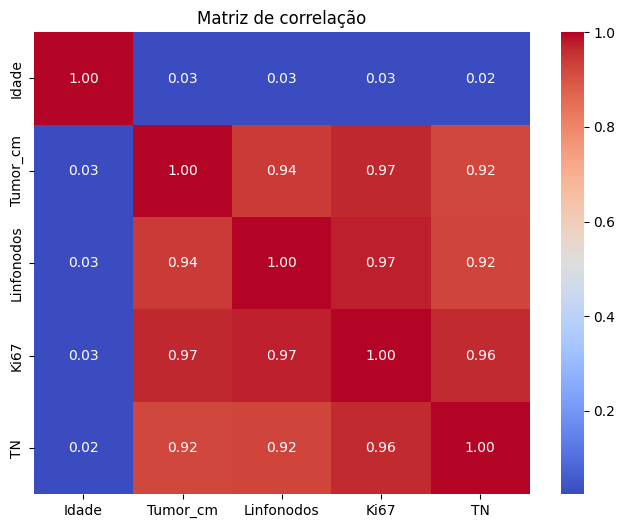

In [465]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_limpo[
        ['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67', 'TN']
    ].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlação')
plt.show()
